In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data = {
    "Mileage": [15,18,20,22,25,28],
    "Engine": [1000,1200,1500,1800,2000,2200],
    "Age": [2,3,5,4,6,7],
    "Price": [500000,600000,750000,900000,1100000,1300000]
}

df = pd.DataFrame(data)

print(df)

   Mileage  Engine  Age    Price
0       15    1000    2   500000
1       18    1200    3   600000
2       20    1500    5   750000
3       22    1800    4   900000
4       25    2000    6  1100000
5       28    2200    7  1300000


In [4]:
X = df[['Mileage','Engine','Age']]
y = df['Price']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = LinearRegression()

In [7]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[60000., 100., 0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Mileage','Engine','Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [8]:
y_pred = model.predict(X_test)

In [9]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison)

   Actual  Predicted
0  500000   400000.0
1  600000   600000.0


In [10]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)

MAE = 50000.000000000175


In [11]:
mse = mean_squared_error(y_test, y_pred)

print("MSE =", mse)

MSE = 5000000000.000011


In [12]:
rmse = np.sqrt(mse)

print("RMSE =", rmse)

RMSE = 70710.67811865483


In [13]:
r2 = r2_score(y_test, y_pred)

print("R2 Score =", r2)

R2 Score = -1.0000000000000044


In [14]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef)

   Feature   Coefficient
0  Mileage  6.000000e+04
1   Engine  1.000000e+02
2      Age  2.154443e-11


In [15]:
new_car = [[24,1800,5]]

price = model.predict(new_car)

print("Predicted Car Price =", price)

Predicted Car Price = [1020000.]


c:\Users\danny\OneDrive\Documents\coding\PBEL (Project-Based Experiential Learning) sessions\PBEL12\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
print("Training Score =", model.score(X_train, y_train))

Training Score = 1.0


In [17]:
print("Testing Score =", model.score(X_test, y_test))

Testing Score = -1.0000000000000044


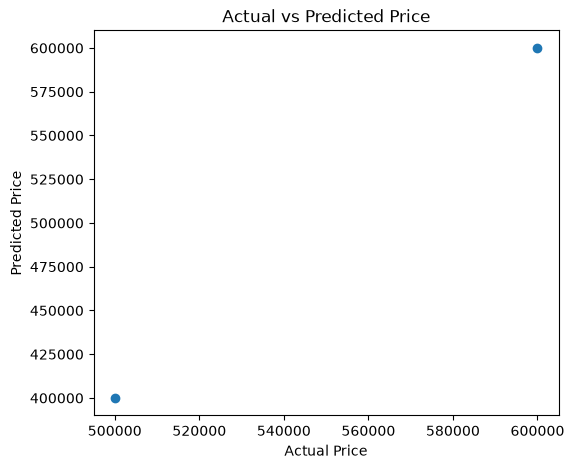

In [18]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

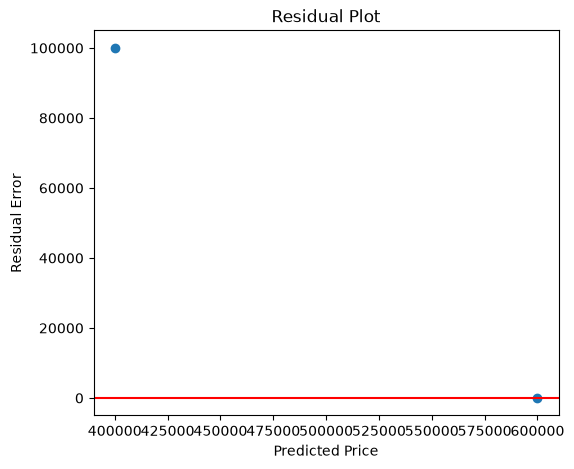

In [19]:
errors = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, errors)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")
plt.title("Residual Plot")

plt.show()

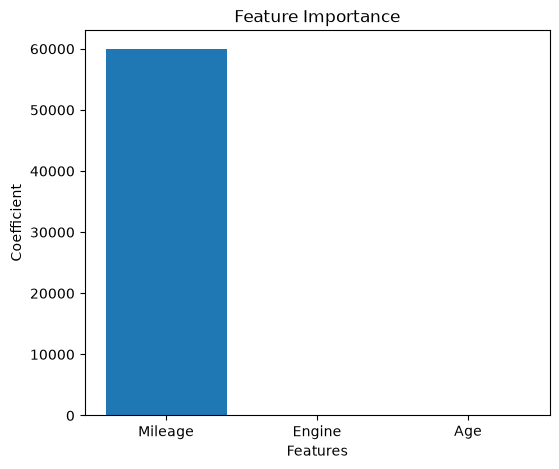

In [20]:
plt.figure(figsize=(6,5))

plt.bar(X.columns, model.coef_)

plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Feature Importance")

plt.show()

In [21]:
print("Intercept =", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(feature, "=", coef)

Intercept = -600000.0
Mileage = 59999.99999999996
Engine = 100.0000000000004
Age = 2.1544432904363475e-11


In [22]:
print("Intercept =", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(feature, "=", coef)

Intercept = -600000.0
Mileage = 59999.99999999996
Engine = 100.0000000000004
Age = 2.1544432904363475e-11
